# 01 — Bernoulli Distribution: Exponential Tilting and Large Deviations

> **Project:** `large-deviations`  
> **Theme:** rare events, exponential tilting, Cramér's theorem, and importance sampling  
> **Distribution:** Bernoulli

This notebook connects three layers:

```text
theory → implementation → numerical experiment
```

The Bernoulli case is deliberately simple, but it is not toy-only: it is the basic building block for default indicators in credit risk,

$$
Y =
\begin{cases}
1, & \text{default},\\
0, & \text{no default}.
\end{cases}
$$

For a portfolio, rare loss events become rare events for sums of Bernoulli-type variables. This notebook uses the one-dimensional Bernoulli setting to make the change-of-measure mechanism completely explicit.

## What this notebook shows

1. The Bernoulli cumulant generating function.
2. The exponential tilt $p\mapsto p_\theta$.
3. The saddle-point choice $\Gamma'(\theta^*)=\ell$.
4. The Bernoulli rate function in Cramér's theorem.
5. A numerical comparison between naive Monte Carlo and exponential-tilting importance sampling.

## Related theory notes

For the detailed derivations behind this notebook, see:

- `docs/foundations/exponential_tilting.md`
- `docs/distributions/bernoulli.md`

> **Scope note:** this is a first applied notebook. It introduces importance sampling empirically and with one exact second-moment diagnostic; the full variance theory can be developed in a later dedicated module.


## 1. Imports and project setup

The notebook is designed to run from either:

- the repository root,
- the `notebooks/` directory,
- or an environment where the package has been installed.

When run inside the repository, it imports the package implementation from `src/large_deviations`.


In [1]:
from pathlib import Path
import sys
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import binom
from IPython.display import display

# Make the project package importable from the repository root or from notebooks/.
cwd = Path.cwd().resolve()
candidate_roots = [cwd, cwd.parent]

for root in candidate_roots:
    src_path = root / "src"
    if src_path.exists() and str(src_path) not in sys.path:
        sys.path.insert(0, str(src_path))

from large_deviations import bernoulli_ld
from large_deviations.plotting import plot_tilting
from large_deviations.tilting import theta_for_tilted_mean, tilting_summary


def binomial_tail_threshold(n: int, level: float) -> int:
    """Return the count threshold for the event S_n / n >= level.

    The small tolerance avoids floating-point artifacts, e.g. ceil(48.00000000001).
    """
    return int(math.ceil(n * level - 1e-12))


plt.rcParams.update({
    "figure.figsize": (10, 6),
    "axes.grid": True,
    "grid.alpha": 0.25,
    "font.size": 11,
})


## 2. Parameters

We choose a Bernoulli random variable with success probability:

$$
p=0.2.
$$

Then we study a rare event where the empirical frequency of successes is at least:

$$
\ell = 0.6.
$$

For $X_1,\dots,X_n\sim \mathrm{Bernoulli}(p)$, define:

$$
\bar X_n = \frac{1}{n}\sum_{i=1}^n X_i.
$$

The event

$$
\bar X_n \geq \ell
$$

is rare because $\ell=0.6$ is far above the true mean $p=0.2$.

In [2]:
p = 0.20
ell = 0.60
n = 80

dist = bernoulli_ld(p)

theta_star = theta_for_tilted_mean(dist, target_mean=ell)
tilt = tilting_summary(dist, theta_star)

p_tilt = float(tilt.tilted_parameter)
gamma_theta = tilt.cgf
rate_ell = dist.rate_function(ell)

summary = pd.DataFrame(
    {
        "quantity": [
            "original success probability p",
            "rare-event threshold ell",
            "sample size n",
            "saddle-point theta*",
            "unit weight multiplier exp(theta*)",
            "tilted success probability p_theta*",
            "CGF Gamma(theta*)",
            "rate function Gamma*(ell)",
        ],
        "value": [
            p,
            ell,
            n,
            theta_star,
            tilt.unit_weight_multiplier,
            p_tilt,
            gamma_theta,
            rate_ell,
        ],
    }
)

display(summary)


,quantity,value
0,original success probability p,0.200000
1,rare-event threshold ell,0.600000
2,sample size n,80.000000
3,saddle-point theta*,1.791759
4,unit weight multiplier exp(theta*),6.000000
5,tilted success probability p_theta*,0.600000
6,CGF Gamma(theta*),0.693147
7,rate function Gamma*(ell),0.381909


## 3. Bernoulli CGF, tilted mean, and saddle point

For $X\sim\mathrm{Bernoulli}(p)$, the cumulant generating function is

$$
\Gamma(\theta)
=
\log\mathbb{E}[e^{\theta X}]
=
\log(1-p+p e^\theta).
$$

The exponentially tilted law is still Bernoulli, with parameter

$$
p_\theta
=
\frac{p e^\theta}{1-p+p e^\theta}.
$$

Since

$$
\Gamma'(\theta)=\mathbb{E}_\theta[X]=p_\theta,
$$

the saddle-point tilt for the rare level $\ell$ is the value $\theta^*$ satisfying

$$
\Gamma'(\theta^*)=\ell.
$$


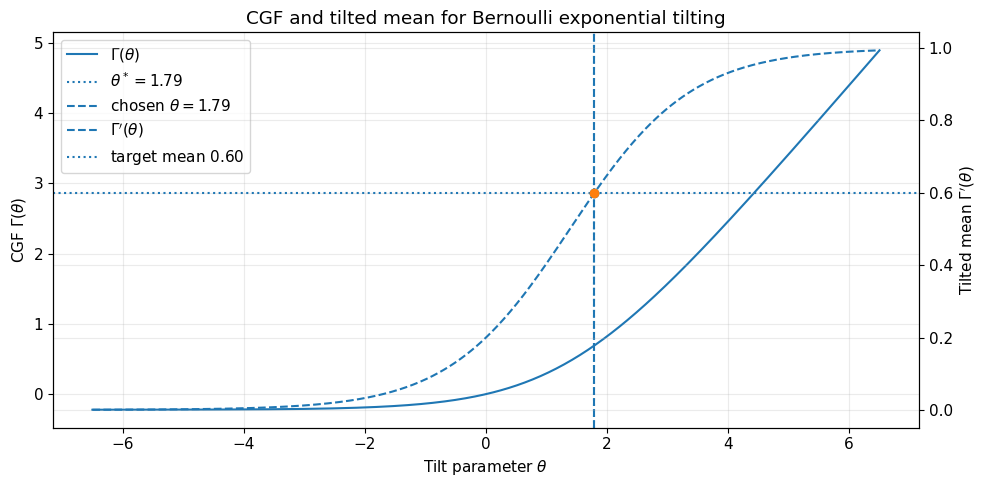

In [3]:
fig, (ax1, ax2) = plot_tilting(
    dist,
    target_mean=ell,
    theta_range=(-6, 6),
)

ax1.set_title("CGF and tilted mean for Bernoulli exponential tilting")
plt.show()


### Reading the graph

The horizontal line is the target level $\ell=0.60$.  
The vertical line marks the saddle point $\theta^*$ such that

$$
\Gamma'(\theta^*)=p_{\theta^*}=\ell.
$$

Here,

$$
0.60=\frac{0.20e^{\theta^*}}{0.80+0.20e^{\theta^*}},
\qquad
e^{\theta^*}=6,
\qquad
\theta^*=\log(6)\approx 1.79.
$$

Under the original law, $\bar X_n$ is centered near $0.20$. Under the tilted law with $\theta^*$, it is centered near $0.60$. This is the key operational idea:

$$
\text{choose } \theta^* \text{ so that the rare target becomes typical under the new measure.}
$$


## 4. Sample-mean view: making the rare event typical

For large deviations, the main object is the empirical mean

$$
\bar X_n = \frac{S_n}{n},
\qquad
S_n=X_1+\cdots+X_n.
$$

Under the original law,

$$
S_n \sim \mathrm{Binomial}(n,p).
$$

Under the tilted law with parameter $\theta^*$,

$$
S_n \sim \mathrm{Binomial}(n,p_{\theta^*}).
$$

Since $p_{\theta^*}=\ell$, the tilted distribution is centered near the rare-event threshold.


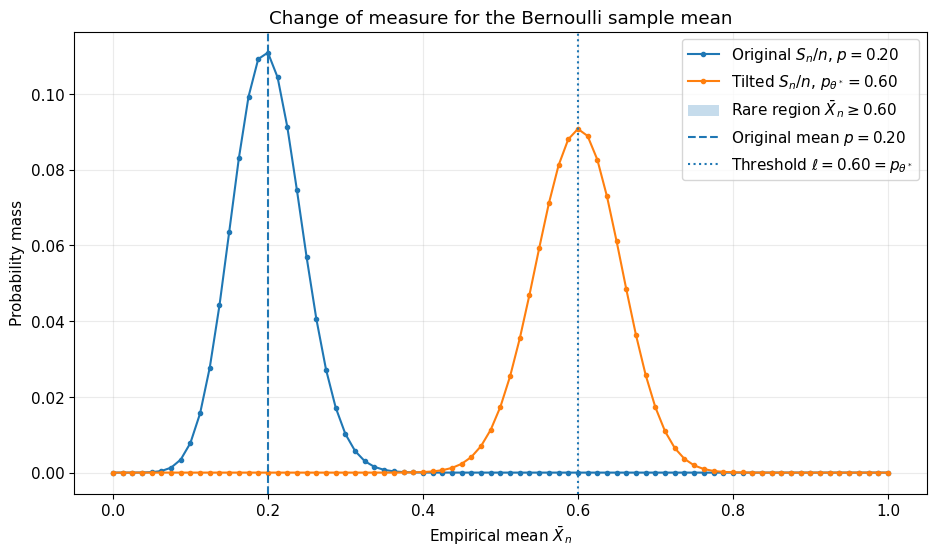

In [4]:
k = np.arange(n + 1)
xbar = k / n

pmf_original = binom.pmf(k, n, p)
pmf_tilted = binom.pmf(k, n, p_tilt)

rare_mask = xbar >= ell

fig, ax = plt.subplots(figsize=(11, 6))

ax.plot(
    xbar,
    pmf_original,
    marker="o",
    markersize=3,
    linewidth=1.5,
    label=rf"Original $S_n/n$, $p={p:.2f}$",
)
ax.plot(
    xbar,
    pmf_tilted,
    marker="o",
    markersize=3,
    linewidth=1.5,
    label=rf"Tilted $S_n/n$, $p_{{\theta^*}}={p_tilt:.2f}$",
)

ax.fill_between(
    xbar,
    pmf_original,
    where=rare_mask,
    alpha=0.25,
    label=rf"Rare region $\bar X_n \geq {ell:.2f}$",
)
ax.axvline(p, linestyle="--", label=rf"Original mean $p={p:.2f}$")
ax.axvline(ell, linestyle=":", label=rf"Threshold $\ell={ell:.2f}=p_{{\theta^*}}$")

ax.set_xlabel(r"Empirical mean $\bar X_n$")
ax.set_ylabel("Probability mass")
ax.set_title("Change of measure for the Bernoulli sample mean")
ax.legend()
plt.show()

## 5. Bernoulli rate function

Cramér's theorem says that rare deviations of $\bar X_n$ decay exponentially.

The rate function is the Fenchel-Legendre transform

$$
\Gamma^*(x)
=
\sup_{\theta\in\mathbb{R}}
\left\{
\theta x-\Gamma(\theta)
\right\}.
$$

For Bernoulli,

$$
\Gamma^*(x)
=
x\log\left(\frac{x}{p}\right)
+
(1-x)\log\left(\frac{1-x}{1-p}\right),
\qquad x\in[0,1].
$$

Outside $[0,1]$, the rate function is infinite. The typical value has zero cost,

$$
\Gamma^*(p)=0,
$$

while the rare target has positive cost,

$$
\Gamma^*(\ell)>0.
$$


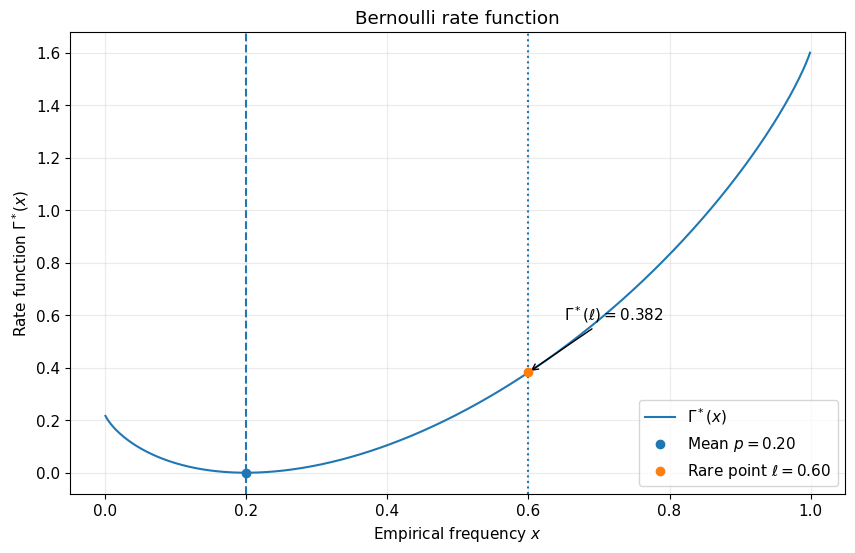

In [5]:
x_grid = np.linspace(0.001, 0.999, 500)
rate_values = np.array([dist.rate_function(x) for x in x_grid])

fig, ax = plt.subplots()

ax.plot(x_grid, rate_values, label=r"$\Gamma^*(x)$")
ax.scatter([p], [dist.rate_function(p)], zorder=5, label=rf"Mean $p={p:.2f}$")
ax.scatter([ell], [rate_ell], zorder=5, label=rf"Rare point $\ell={ell:.2f}$")
ax.axvline(p, linestyle="--")
ax.axvline(ell, linestyle=":")

ax.annotate(
    rf"$\Gamma^*(\ell)={rate_ell:.3f}$",
    xy=(ell, rate_ell),
    xytext=(ell + 0.05, rate_ell + 0.2),
    arrowprops={"arrowstyle": "->"},
)

ax.set_xlabel(r"Empirical frequency $x$")
ax.set_ylabel(r"Rate function $\Gamma^*(x)$")
ax.set_title("Bernoulli rate function")
ax.legend()
plt.show()

### Interpretation

$\Gamma^*(x)$ is the exponential cost of observing an empirical frequency $x$ instead of the typical frequency $p$.

The large-deviation reading is

$$
\mathbb{P}\left(\bar{X}_n \approx x\right)
\approx
\exp\left(-n\Gamma^*(x)\right).
$$

So the rate function is not a probability. It is the leading exponent controlling how fast rare probabilities decay.


## 6. Exact tail probability vs Cramér logarithmic scale

For Bernoulli random variables,

$$
S_n \sim \mathrm{Binomial}(n,p).
$$

The exact rare-event probability is

$$
\mathbb{P}(\bar X_n \geq \ell)
=
\mathbb{P}(S_n \geq \lceil n\ell\rceil).
$$

Cramér's theorem gives the logarithmic approximation

$$
\mathbb{P}(\bar X_n \geq \ell)
\approx
e^{-n\Gamma^*(\ell)}.
$$

The precise asymptotic statement is

$$
-\frac{1}{n}\log \mathbb{P}(\bar X_n \geq \ell)
\to
\Gamma^*(\ell).
$$


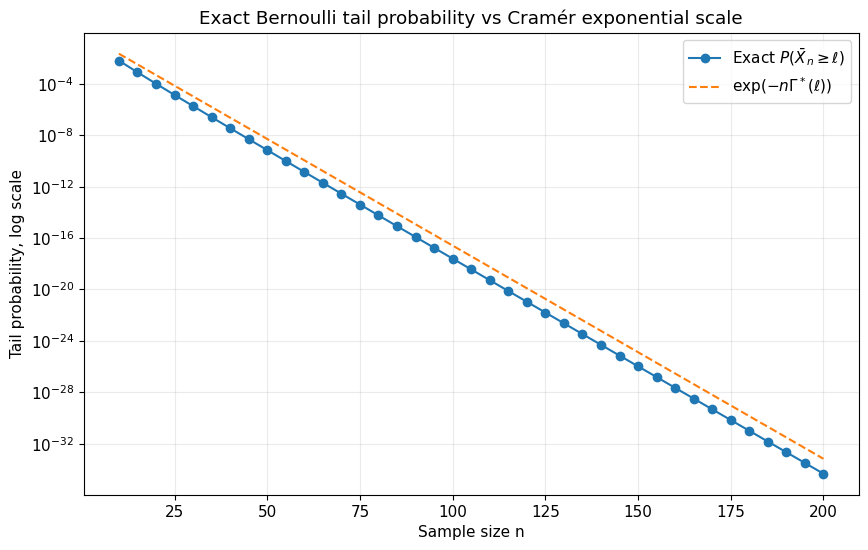

In [6]:
n_values = np.arange(10, 201, 5)

exact_probs = []
cramer_probs = []
log_rates = []

for n_i in n_values:
    threshold_count = binomial_tail_threshold(n_i, ell)
    exact_prob = binom.sf(threshold_count - 1, n_i, p)
    exact_probs.append(exact_prob)
    cramer_probs.append(math.exp(-n_i * rate_ell))
    log_rates.append(-math.log(exact_prob) / n_i)

exact_probs = np.array(exact_probs)
cramer_probs = np.array(cramer_probs)
log_rates = np.array(log_rates)

fig, ax = plt.subplots()

ax.semilogy(n_values, exact_probs, marker="o", label=r"Exact $P(\bar X_n \geq \ell)$")
ax.semilogy(n_values, cramer_probs, linestyle="--", label=r"$\exp(-n\Gamma^*(\ell))$")

ax.set_xlabel("Sample size n")
ax.set_ylabel("Tail probability, log scale")
ax.set_title("Exact Bernoulli tail probability vs Cramér exponential scale")
ax.legend()
plt.show()

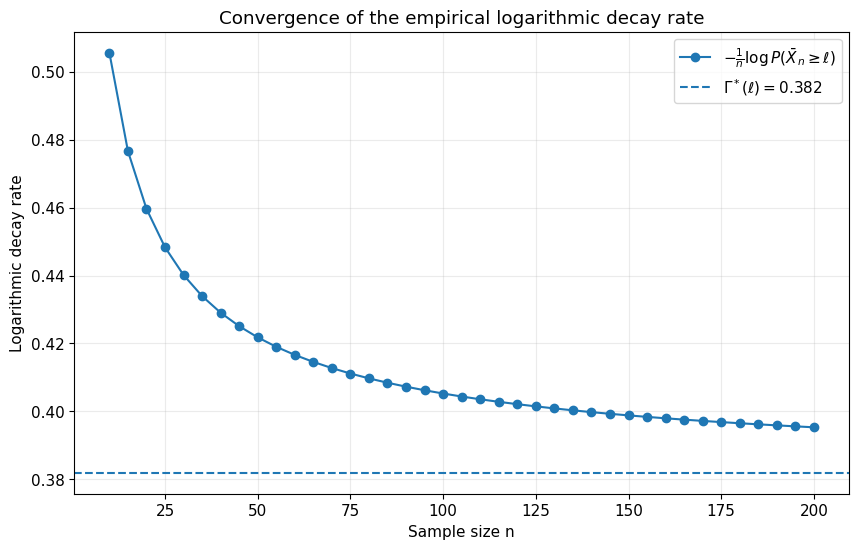

In [7]:
fig, ax = plt.subplots()

ax.plot(n_values, log_rates, marker="o", label=r"$-\frac{1}{n}\log P(\bar X_n \geq \ell)$")
ax.axhline(rate_ell, linestyle="--", label=rf"$\Gamma^*(\ell)={rate_ell:.3f}$")

ax.set_xlabel("Sample size n")
ax.set_ylabel("Logarithmic decay rate")
ax.set_title("Convergence of the empirical logarithmic decay rate")
ax.legend()
plt.show()

### Interpretation

The first plot compares the exact binomial tail with the leading exponential scale $e^{-n\Gamma^*(\ell)}$.

Cramér's theorem does **not** claim equality at finite $n$. It says that both quantities have the same leading slope on the logarithmic scale. The second plot checks the more robust diagnostic:

$$
-\frac{1}{n}
\log \mathbb{P}\left(\bar{X}_n \geq \ell\right)
\to
\Gamma^*(\ell).
$$


## 7. Importance sampling estimator

The exponential-tilting identity is

$$
\mathbb{P}\left(\bar X_n \geq \ell\right)
=
\mathbb{E}_{\theta}
\left[
1_{\{\bar X_n \geq \ell\}}
e^{-\theta S_n+n\Gamma(\theta)}
\right].
$$

The likelihood-ratio correction is

$$
e^{-\theta S_n+n\Gamma(\theta)}.
$$

For $\theta=\theta^*$, the event $\bar X_n\geq \ell$ is common under the tilted law, but the likelihood ratio keeps the estimator unbiased for the original Bernoulli($p$) probability.

We compare naive Monte Carlo and tilted importance sampling for $n=80$, where the exact probability is around $10^{-15}$.


In [8]:
rng = np.random.default_rng(12345)

M = 50_000
n_is = 80
threshold_count = binomial_tail_threshold(n_is, ell)

exact_prob = binom.sf(threshold_count - 1, n_is, p)

# Naive Monte Carlo under original Bernoulli(p)
S_naive = rng.binomial(n_is, p, size=M)
naive_samples = (S_naive >= threshold_count).astype(float)
naive_estimate = naive_samples.mean()
naive_se_empirical = naive_samples.std(ddof=1) / math.sqrt(M)

# Importance sampling under tilted Bernoulli(p_tilt)
S_tilt = rng.binomial(n_is, p_tilt, size=M)
weights = np.exp(-theta_star * S_tilt + n_is * gamma_theta)
is_samples = (S_tilt >= threshold_count) * weights
is_estimate = is_samples.mean()
is_se_empirical = is_samples.std(ddof=1) / math.sqrt(M)

# Exact per-sample variances for the two estimators.
naive_var_exact = exact_prob * (1.0 - exact_prob)

counts = np.arange(threshold_count, n_is + 1)
tilted_pmf_tail = binom.pmf(counts, n_is, p_tilt)
weights_tail = np.exp(-theta_star * counts + n_is * gamma_theta)
is_second_moment_exact = np.sum(tilted_pmf_tail * weights_tail**2)
is_var_exact = is_second_moment_exact - exact_prob**2

results = pd.DataFrame(
    {
        "method": ["Naive Monte Carlo", "Exponential tilting IS"],
        "estimate": [naive_estimate, is_estimate],
        "empirical_standard_error": [naive_se_empirical, is_se_empirical],
        "exact_relative_error_for_M": [
            math.sqrt(naive_var_exact / M) / exact_prob,
            math.sqrt(is_var_exact / M) / exact_prob,
        ],
        "event_hits": [
            int(naive_samples.sum()),
            int((S_tilt >= threshold_count).sum()),
        ],
        "expected_event_hits_under_sampling_law": [
            M * exact_prob,
            M * binom.sf(threshold_count - 1, n_is, p_tilt),
        ],
    }
)

diagnostics = pd.DataFrame(
    {
        "quantity": [
            "exact probability",
            "threshold count ceil(n ell)",
            "tilted event probability",
            "exact IS second moment",
            "per-sample variance reduction: naive / IS",
        ],
        "value": [
            exact_prob,
            threshold_count,
            binom.sf(threshold_count - 1, n_is, p_tilt),
            is_second_moment_exact,
            naive_var_exact / is_var_exact,
        ],
    }
)

display(results)
display(diagnostics)


,method,estimate,empirical_standard_error,exact_relative_error_for_M,event_hits,expected_event_hits_under_sampling_law
0,Naive Monte Carlo,0.000000e+00,0.000000e+00,58577.592058,0,2.914318e-10
1,Exponential tilting IS,5.899999e-15,6.918389e-17,0.011799,27526,2.741833e+04


,quantity,value
0,exact probability,5.828636e-15
1,threshold count ceil(n ell),4.800000e+01
2,tilted event probability,5.483666e-01
3,exact IS second moment,2.704396e-28
4,per-sample variance reduction: naive / IS,2.464887e+13


### What the table shows

The naive estimator is unbiased in theory, but the expected number of hits is essentially zero for $M=50{,}000$. A zero estimate is therefore not surprising; it is the typical practical failure mode.

The tilted estimator samples from a law where the event is common, then reweights each observation. The exact second-moment diagnostic gives a per-sample variance reduction on the order of $10^{13}$ for this parameter choice.


## 8. Convergence paths: naive MC vs tilted IS

The previous table gives numerical diagnostics. The next plot shows the mechanism visually.

For readability, the plot uses a moderately rare case. The point is not to prove a variance-reduction theorem here, but to show why the tilted estimator is more stable: it produces informative weighted observations much more regularly.


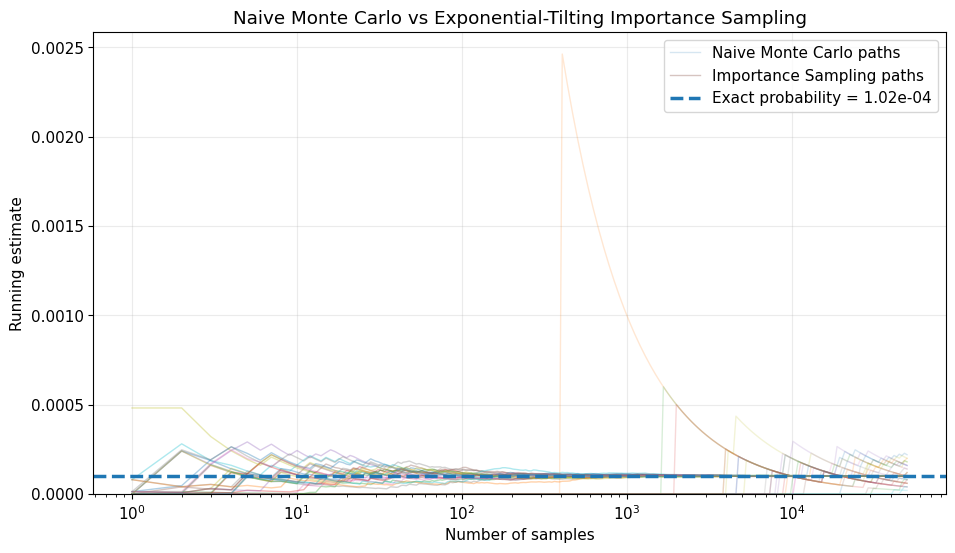

{'n': 20,
 'threshold_count': 12,
 'theta_star': 1.7917594695091261,
 'p_tilt': 0.6000000000674571,
 'true_probability': np.float64(0.0001017287651570485)}

In [9]:
def compare_naive_mc_vs_importance_sampling(
    p: float = 0.2,
    ell: float = 0.6,
    n: int = 20,
    n_samples: int = 50_000,
    n_paths: int = 25,
    random_seed: int = 42,
):
    """Compare convergence paths of naive MC and exponential-tilting IS.

    Event:
        S_n / n >= ell

    The event is only moderately rare here so that naive Monte Carlo
    still produces visible jumps on the plot.
    """
    rng = np.random.default_rng(random_seed)

    dist = bernoulli_ld(p)

    theta_star_local = theta_for_tilted_mean(dist, target_mean=ell)
    local_tilt = tilting_summary(dist, theta_star_local)

    p_tilt_local = float(local_tilt.tilted_parameter)
    gamma_local = local_tilt.cgf

    threshold_count = binomial_tail_threshold(n, ell)
    true_probability = binom.sf(threshold_count - 1, n, p)

    sample_grid = np.unique(
        np.logspace(0, np.log10(n_samples), 300).astype(int)
    )

    naive_paths = []
    is_paths = []

    for _ in range(n_paths):
        # Naive Monte Carlo under Bernoulli(p)
        naive_samples = rng.binomial(n=n, p=p, size=n_samples)
        naive_indicators = (naive_samples >= threshold_count).astype(float)
        naive_running = np.cumsum(naive_indicators) / np.arange(1, n_samples + 1)

        # Importance sampling under Bernoulli(p_tilt)
        tilted_samples = rng.binomial(n=n, p=p_tilt_local, size=n_samples)
        indicators = (tilted_samples >= threshold_count).astype(float)

        likelihood_ratios = np.exp(
            -theta_star_local * tilted_samples + n * gamma_local
        )

        weighted_samples = indicators * likelihood_ratios
        is_running = np.cumsum(weighted_samples) / np.arange(1, n_samples + 1)

        naive_paths.append(naive_running[sample_grid - 1])
        is_paths.append(is_running[sample_grid - 1])

    fig, ax = plt.subplots(figsize=(11, 6))

    naive_line = None
    is_line = None

    for i, path in enumerate(naive_paths):
        line, = ax.plot(sample_grid, path, alpha=0.18, linewidth=1)
        if i == 0:
            naive_line = line

    for i, path in enumerate(is_paths):
        line, = ax.plot(sample_grid, path, alpha=0.35, linewidth=1)
        if i == 0:
            is_line = line

    exact_line = ax.axhline(
        true_probability,
        linestyle="--",
        linewidth=2.5,
        label=f"Exact probability = {true_probability:.2e}",
    )

    ax.set_xscale("log")
    ax.set_ylim(bottom=0)
    ax.set_xlabel("Number of samples")
    ax.set_ylabel("Running estimate")
    ax.set_title("Naive Monte Carlo vs Exponential-Tilting Importance Sampling")
    ax.legend(
        handles=[naive_line, is_line, exact_line],
        labels=[
            "Naive Monte Carlo paths",
            "Importance Sampling paths",
            f"Exact probability = {true_probability:.2e}",
        ],
    )
    ax.grid(True, alpha=0.25)

    plt.show()

    return {
        "n": n,
        "threshold_count": threshold_count,
        "theta_star": theta_star_local,
        "p_tilt": p_tilt_local,
        "true_probability": true_probability,
    }


comparison = compare_naive_mc_vs_importance_sampling(
    p=0.2,
    ell=0.6,
    n=20,
    n_samples=50_000,
    n_paths=25,
    random_seed=42,
)

comparison


### Interpretation of the convergence plot

Naive Monte Carlo paths stay flat for long periods because most simulations do not hit the rare event. When a hit finally appears, the running estimate jumps.

The tilted estimator sees the event more often, so its weighted running estimates fluctuate more regularly around the true probability.


## 9. Code correspondence

The implementation in `large_deviations.distributions.bernoulli_ld` exposes the main large-deviation objects.

| Mathematical object | Formula | Code object |
|---|---|---|
| Cumulant generating function | $\Gamma(\theta)=\log(1-p+p e^\theta)$ | `dist.cgf(theta)` |
| Tilted parameter | $p_\theta=\frac{p e^\theta}{1-p+p e^\theta}$ | `dist.tilted_parameter(theta)` |
| Mean under tilted law | $\mathbb{E}_\theta[X]=p_\theta$ | `dist.mean_under_tilt(theta)` |
| Rate function | $\Gamma^*(x)=x\log(x/p)+(1-x)\log((1-x)/(1-p))$ | `dist.rate_function(x)` |
| Domain | $D(\Gamma)=\mathbb{R}$ | `dist.domain_contains(theta)` |

We can verify these links numerically.


In [ ]:
check_theta = theta_star
check_x = ell

checks = pd.DataFrame(
    {
        "identity": [
            "Gamma(0) = 0",
            "p_theta at theta=0 equals p",
            "mean_under_tilt(theta*) equals ell",
            "Legendre identity at saddle point",
            "rate_function(p) = 0",
        ],
        "left_side": [
            dist.cgf(0.0),
            dist.tilted_parameter(0.0),
            dist.mean_under_tilt(check_theta),
            dist.rate_function(check_x),
            dist.rate_function(p),
        ],
        "right_side": [
            0.0,
            p,
            ell,
            check_theta * check_x - dist.cgf(check_theta),
            0.0,
        ],
    }
)

checks["absolute_error"] = (checks["left_side"] - checks["right_side"]).abs()
display(checks)

## 10. Takeaways

For a Bernoulli random variable,

$$
\Gamma(\theta)=\log(1-p+p e^\theta),
\qquad
p_\theta=
\frac{p e^\theta}{1-p+p e^\theta}.
$$

For the rare event $\bar X_n\geq \ell$, the saddle-point tilt satisfies

$$
\Gamma'(\theta^*)=p_{\theta^*}=\ell.
$$

This changes the sampling law so that the rare event becomes typical under the tilted measure. The likelihood ratio

$$
e^{-\theta^* S_n+n\Gamma(\theta^*)}
$$

then corrects the estimator back to the original Bernoulli($p$) law.

The large-deviation rate function is

$$
\Gamma^*(x)
=
x\log\left(\frac{x}{p}\right)
+
(1-x)\log\left(\frac{1-x}{1-p}\right),
\qquad x\in[0,1],
$$

and Cramér's theorem says

$$
-\frac{1}{n}\log\mathbb{P}(\bar X_n\geq \ell)
\to
\Gamma^*(\ell).
$$

**Next notebook:** the Gaussian case, where exponential tilting shifts the mean,

$$
X\sim \mathcal{N}(0,\sigma^2)
\quad\Longrightarrow\quad
X\sim \mathcal{N}(\theta\sigma^2,\sigma^2)
\text{ under } \mathbb{P}_\theta.
$$
